---

**Load essential libraries**

---

In [ ]:
import numpy as np
import sys
import random
import matplotlib.pyplot as plt
plt.style.use('dark_background')
%matplotlib inline

import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Lambda
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model

2.15.0


---

Mount Google Drive if running on Colab

---

In [ ]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    # Change path below starting from /content/drive/MyDrive/Colab Notebooks/
    # depending on how data is organized inside your Colab Notebooks folder in
    # Google Drive
    DIR = '/content/drive/My Drive/Deep Learning'
    DATA_DIR = DIR+'/Data/'
else:
    DATA_DIR = 'Data/'

Mounted at /content/drive


---

Load MNIST Data

---

In [ ]:
## Load MNIST data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1]*X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1]*X_test.shape[2])

num_labels = len(np.unique(y_train))
num_features = X_train.shape[1]
num_samples = X_train.shape[0]

# One-hot encode class labels
Y_train = tf.keras.utils.to_categorical(y_train)
Y_test = tf.keras.utils.to_categorical(y_test)

# Normalize the samples (images) using the training data
xmax = np.amax(X_train)
xmin = np.amin(X_train)
X_train = (X_train - xmin) / (xmax - xmin) # all train features turn into a number between 0 and 1
X_test = (X_test - xmin)/(xmax - xmin)

print('MNIST set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))
print('Number of output labels = %d'%(num_labels))

11490434/11490434 [==============================] - 0s 0us/step
MNIST set
---------------------
Number of training samples = 60000
Number of features = 784
Number of output labels = 10


# New Section

---

Hyperparameters for the model

---

In [ ]:
## Hyperparameters for the model
batch_size = 256
max_epochs = 10
learning_rate = 1e-03
reg_strength = 0.1

---

We have looked at 2 different approaches to build custom models using TensorFlow 2:

1. sequential API
2. model subclassing ([Making new layers and models via subclassing](https://www.tensorflow.org/guide/keras/making_new_layers_and_models_via_subclassing))

The 3rd, and the last approach is via the functional API.

---

---

**Approach-1**: here we build the model using the sequential API of TensorFlow Keras, compile, and train it.

---

In [ ]:
# Define model architecture (2 layers, 128 nodes in hidden layer)
model = Sequential()
model.add(Dense(128,
                dtype = 'float64',
                activation = tf.nn.leaky_relu,
                kernel_regularizer = tf.keras.regularizers.l2(l2 = reg_strength)
                ))
model.add(Dense(num_labels,
                dtype = 'float64',
                activation = tf.keras.activations.softmax,
                kernel_regularizer = tf.keras.regularizers.l2(l2 = reg_strength)
                ))



# Compile model
opt = tf.keras.optimizers.Adam(learning_rate = learning_rate) # optimizer
loss_fn = tf.keras.losses.CategoricalCrossentropy()  # loss function
model.compile(optimizer = opt, loss = loss_fn, metrics = ['acc'])

# Train model and simultaneously test on the test set
history = model.fit(X_train, Y_train,
                    batch_size = batch_size,
                    epochs = max_epochs,
                    validation_data = (X_test, Y_test))

Epoch 1/50
235/235 [==============================] - 6s 20ms/step - loss: 4.5418 - acc: 0.7690 - val_loss: 1.9514 - val_acc: 0.7597
Epoch 2/50
235/235 [==============================] - 3s 14ms/step - loss: 1.9489 - acc: 0.7535 - val_loss: 1.9262 - val_acc: 0.7761
Epoch 3/50
235/235 [==============================] - 3s 14ms/step - loss: 1.9346 - acc: 0.7421 - val_loss: 1.9183 - val_acc: 0.7561
Epoch 4/50
235/235 [==============================] - 4s 17ms/step - loss: 1.9289 - acc: 0.7386 - val_loss: 1.9088 - val_acc: 0.7348
Epoch 5/50
235/235 [==============================] - 4s 17ms/step - loss: 1.9255 - acc: 0.7397 - val_loss: 1.9089 - val_acc: 0.7433
Epoch 6/50
235/235 [==============================] - 4s 16ms/step - loss: 1.9250 - acc: 0.7391 - val_loss: 1.9093 - val_acc: 0.7442
Epoch 7/50
235/235 [==============================] - 3s 14ms/step - loss: 1.9232 - acc: 0.7406 - val_loss: 1.9054 - val_acc: 0.7525
Epoch 8/50
235/235 [==============================] - 4s 18ms/step - 

In [ ]:
print(model.summary)

<bound method Model.summary of <__main__.Model object at 0x7a608ec92b00>>


---

Plot train and test loss vs. epoch and train and test accuracies vs. epoch

---

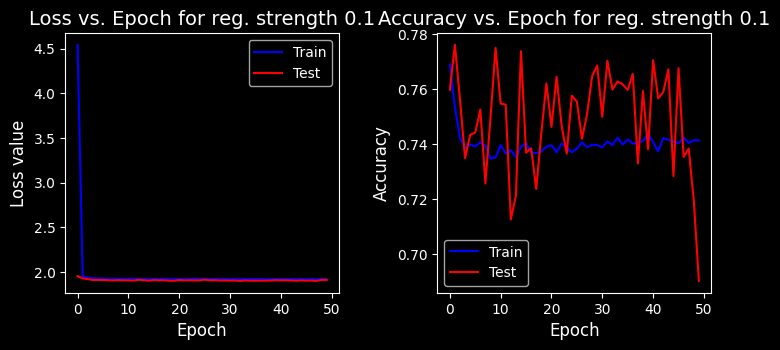

In [ ]:
# Plot train and test loss vs. epoch and
# train and test accuracies vs. epoch:
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
fig.tight_layout(pad = 4.0)
ax[0].plot( history.history['loss'], 'b', label = 'Train')
ax[0].plot( history.history['val_loss'], 'r', label = 'Test')
ax[0].set_xlabel('Epoch', fontsize = 12)
ax[0].set_ylabel('Loss value', fontsize = 12)
ax[0].legend()
ax[0].set_title(f'Loss vs. Epoch for reg. strength {reg_strength}', fontsize = 14);

ax[1].plot( history.history['acc'], 'b', label = 'Train')
ax[1].plot( history.history['val_acc'], 'r', label = 'Test')
ax[1].set_xlabel('Epoch', fontsize = 12)
ax[1].set_ylabel('Accuracy', fontsize = 12)
ax[1].legend()
ax[1].set_title('Accuracy vs. Epoch for reg. strength 0.1', fontsize = 14);

---

**Approach-2**: here we build the model by subclassing the TensorFlow Keras $\texttt{Model}$ class followed by definition of of layers in $\texttt{__init__}$ and implementation of the model's forward pass in $\texttt{call()}$.

---

In [ ]:
## Define 2-layer neural network architecture with 128 nodes in the hidden layer
# Define model
class Model1(tf.keras.models.Model):
    def __init__(self):
        super(Model1, self).__init__()
        initializer = tf.keras.initializers.RandomUniform(minval=-0.5, maxval=0.5)
        self.layer1 = tf.keras.layers.Dense(128,
                                            dtype = 'float64',
                                            bias_initializer = initializer,
                                            activation = tf.nn.leaky_relu,
                                            kernel_regularizer = tf.keras.regularizers.l2(l2 = reg_strength)
                                            )
        self.layer2 = tf.keras.layers.Dense(num_labels,
                                            dtype = 'float64',
                                            bias_initializer = initializer,
                                            activation = tf.keras.activations.softmax,
                                            kernel_regularizer = tf.keras.regularizers.l2(l2 = reg_strength)
                                            )

    # Forward pass for the model
    def call(self, inputs):
        a = self.layer1(inputs)
        a = self.layer2(a)
        return a

---

Compile and train the model.

---

In [ ]:
## Compile model
model = Model1()
opt = tf.keras.optimizers.Adam(learning_rate = learning_rate) # optimizer
loss_fn = tf.keras.losses.CategoricalCrossentropy()  # loss function
model.compile(optimizer = opt, loss = loss_fn, metrics = ['acc'])

# Train model and simultaneously test on the test set
history = model.fit(X_train, Y_train,
                    batch_size = 100,
                    epochs = max_epochs,
                    validation_data = (X_test, Y_test))

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


600/600 [==============================] - 6s 9ms/step - loss: 2.9869 - acc: 0.7523 - val_loss: 1.9312 - val_acc: 0.7233
Epoch 2/50
600/600 [==============================] - 6s 10ms/step - loss: 1.9354 - acc: 0.7361 - val_loss: 1.9153 - val_acc: 0.7459
Epoch 3/50
600/600 [==============================] - 5s 9ms/step - loss: 1.9308 - acc: 0.7296 - val_loss: 1.9117 - val_acc: 0.7261
Epoch 4/50
600/600 [==============================] - ETA: 0s - loss: 1.9294 - acc: 0.7301

KeyboardInterrupt: 

---

In **Approach-2** where we subclassed the Model class, we can also explicitly write down the optimization step using $\texttt{GradientTape()}$ and train the model

---

In [ ]:
## Convert numpy to tf.data.datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(batch_size)

In [ ]:
## Function to compute gradient of loss and update weights
@tf.function
# making use of above it makes it fast, this can be run over cellphones and servers etc
def train(model, loss_fn, opt, input):
  with tf.GradientTape() as g:
    pred = model(input[0]) # 0 - features
    loss_batch = loss_fn(input[1], pred) # 1 - true value
  gradients = g.gradient(loss_batch, model.trainable_variables)
  opt.apply_gradients(zip(gradients, model.trainable_variables))
  return loss_batch

In [ ]:
# Create neural network model with 128 nodes in the hidden layer
model = Model1()
opt = tf.keras.optimizers.Adam(learning_rate = learning_rate) # optimizer
loss_fn = tf.keras.losses.CategoricalCrossentropy()  # loss function

# Varible to store training loss per epoch
loss_train_epoch = tf.keras.metrics.Mean()
loss_train_epoch_plot = np.empty(max_epochs)

# Iterate over epochs
for epoch in range(max_epochs):
  for step, train_batch_features in enumerate(train_dataset):
    loss_batch = train(model, loss_fn, opt, train_batch_features)
    # Append training loss
    loss_train_epoch(loss_batch)
  loss_train_epoch_plot[epoch] = loss_train_epoch.result().numpy()
  print(f'Epoch {epoch+1}, loss = {loss_train_epoch_plot[epoch]}')

Epoch 1, loss = 0.46199479699134827
Epoch 2, loss = 0.3503642976284027


KeyboardInterrupt: 

sequential  - disadvantage -  no graph no mul inp no mul out

---

**Approach-3**: here we build the model using the functional API of TensorFlow.

---

# Approach 3

used when we have multiple inputs and multiple outputs. multiple inputs means more than one dataset and multiple output means

In [ ]:
## Load MNIST dataset without flattening (reshaping) the images
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print(X_train.shape)
print(X_test.shape)

num_labels = len(np.unique(y_train))
num_features = X_train.shape[1]
num_samples = X_train.shape[0]

# One-hot encode class labels
Y_train = tf.keras.utils.to_categorical(y_train)
Y_test = tf.keras.utils.to_categorical(y_test)

# Normalize the samples (images) using the training data
xmax = np.amax(X_train)
xmin = np.amin(X_train)
X_train = (X_train - xmin) / (xmax - xmin) # all train features turn into a number between 0 and 1
X_test = (X_test - xmin)/(xmax - xmin)

print('MNIST set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))
print('Number of output labels = %d'%(num_labels))

(60000, 28, 28)
(10000, 28, 28)
MNIST set
---------------------
Number of training samples = 60000
Number of features = 28
Number of output labels = 10


In [ ]:
# Define the input layer
input_layer = Input(shape = (28, 28))

# Stack the layers using the syntax: new_layer() (previous_layer)
flatten_layer = Flatten()(input_layer)

layer1 = Dense(128, activation = tf.nn.leaky_relu)(flatten_layer)
output_layer = Dense(num_labels, activation = tf.keras.activations.softmax)(layer1)

model = Model(inputs = input_layer, outputs = output_layer)


In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate = learning_rate) # optimizer
loss_fn = tf.keras.losses.CategoricalCrossentropy()  # loss function
model.compile(optimizer = opt, loss = loss_fn, metrics = ['acc'])

# Train model and simultaneously test on the test set
history = model.fit(X_train, Y_train,
                    batch_size = 100,
                    epochs = max_epochs,
                    validation_data = (X_test, Y_test))

Epoch 1/10
600/600 [==============================] - 4s 5ms/step - loss: 5.2920 - acc: 0.8738 - val_loss: 1.6627 - val_acc: 0.9127
Epoch 2/10
600/600 [==============================] - 2s 4ms/step - loss: 1.4650 - acc: 0.9232 - val_loss: 1.2778 - val_acc: 0.9307
Epoch 3/10
600/600 [==============================] - 3s 4ms/step - loss: 1.1478 - acc: 0.9388 - val_loss: 1.2630 - val_acc: 0.9410
Epoch 4/10
600/600 [==============================] - 2s 4ms/step - loss: 0.9135 - acc: 0.9488 - val_loss: 1.2620 - val_acc: 0.9446
Epoch 5/10
600/600 [==============================] - 4s 6ms/step - loss: 0.8151 - acc: 0.9545 - val_loss: 1.1437 - val_acc: 0.9465
Epoch 6/10
600/600 [==============================] - 2s 4ms/step - loss: 0.7473 - acc: 0.9590 - val_loss: 1.1022 - val_acc: 0.9420
Epoch 7/10
600/600 [==============================] - 2s 4ms/step - loss: 0.7514 - acc: 0.9588 - val_loss: 1.0150 - val_acc: 0.9549
Epoch 8/10
600/600 [==============================] - 3s 5ms/step - loss: 0.

---

Siamese neural network - (multiple input problem)

![](https://dsm01pap002files.storage.live.com/y4m4YOFCC_sbCAbXCq7NQU6A2WruYAWuAighVI6h0pyQ8cPKVLxXOsmoDld5x30YlDiYqN_8O92TvfkGAoj3mGOWI8a3zazkfvVjccQZdimepRQ6a3QTe7CjNtUgXDp5xGZgseO_ODki5iA1lgikBzCy0vg52LJwyvzfLsT7ZjxapEy9Ej2aYbN27m0fdesXHHA?width=415&height=372&cropmode=none)

---

In [ ]:
## Normalize the samples (images) using the training data
xmax = np.amax(X_train)
xmin = np.amin(X_train)
X_train = (X_train - xmin) / (xmax - xmin) # all train features turn into a number between 0 and 1
X_test = (X_test - xmin)/(xmax - xmin)



---


**Function to create pairs of images** (for function source, [click here](https://keras.io/examples/vision/siamese_contrastive/))

We will train the model to differentiate between digits of different classes. For example, digit 0 needs to be differentiated from the rest of the digits (1 through 9), digit 1 - from 0 and 2 through 9, and so on. To carry this out, we will select N random images from class A (for example, for digit 0) and pair them with N random images from another class B (for example, for digit 1). Then, we can repeat this process for all classes of digits (until digit 9). Once we have paired digit 0 with other digits, we can repeat this process for the remaining classes for the rest of the digits (from 1 until 9).


---



In [ ]:
def make_pairs(x, y):
    """Creates a tuple containing image pairs with corresponding label.

    Arguments:
        x: List containing images, each index in this list corresponds to one image.
        y: List containing labels, each label with datatype of `int`.

    Returns:
        Tuple containing two numpy arrays as (pairs_of_samples, labels),
        where pairs_of_samples' shape is (2len(x), 2,n_features_dims) and
        labels are a binary array of shape (2len(x)).
    """

    num_classes = max(y) + 1
    digit_indices = [np.where(y == i)[0] for i in range(num_classes)]

    pairs = []
    labels = []

    for idx1 in range(len(x)):
        # add a matching example
        x1 = x[idx1]
        label1 = y[idx1]
        idx2 = random.choice(digit_indices[label1])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [1]

        # add a non-matching example
        label2 = random.randint(0, num_classes - 1)
        while label2 == label1:
            label2 = random.randint(0, num_classes - 1)

        idx2 = random.choice(digit_indices[label2])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [0]

    return np.array(pairs), np.array(labels).astype("float32")

---

Create train and test image pairs

---

In [ ]:
# Make train pairs
X_train_pairs, y_train_pairs = make_pairs(X_train, y_train)

# Make test pairs
X_test_pairs, y_test_pairs = make_pairs(X_test, y_test)



---

Function for visualizing the paired data (for function source, [click here](https://keras.io/examples/vision/siamese_contrastive/))


---



In [ ]:
def visualize(pairs, labels, to_show=6, num_col=3, predictions=None, test=False):
    """Creates a plot of pairs and labels, and prediction if it's test dataset.

    Arguments:
        pairs: Numpy Array, of pairs to visualize, having shape
               (Number of pairs, 2, 28, 28).
        to_show: Int, number of examples to visualize (default is 6)
                `to_show` must be an integral multiple of `num_col`.
                 Otherwise it will be trimmed if it is greater than num_col,
                 and incremented if if it is less then num_col.
        num_col: Int, number of images in one row - (default is 3)
                 For test and train respectively, it should not exceed 3 and 7.
        predictions: Numpy Array of predictions with shape (to_show, 1) -
                     (default is None)
                     Must be passed when test=True.
        test: Boolean telling whether the dataset being visualized is
              train dataset or test dataset - (default False).

    Returns:
        None.
    """

    # Define num_row
    # If to_show % num_col != 0
    #    trim to_show,
    #       to trim to_show limit num_row to the point where
    #       to_show % num_col == 0
    #
    # If to_show//num_col == 0
    #    then it means num_col is greater then to_show
    #    increment to_show
    #       to increment to_show set num_row to 1
    num_row = to_show // num_col if to_show // num_col != 0 else 1

    # `to_show` must be an integral multiple of `num_col`
    #  we found num_row and we have num_col
    #  to increment or decrement to_show
    #  to make it integral multiple of `num_col`
    #  simply set it equal to num_row * num_col
    to_show = num_row * num_col

    # Plot the images
    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))
    for i in range(to_show):

        # If the number of rows is 1, the axes array is one-dimensional
        if num_row == 1:
            ax = axes[i % num_col]
        else:
            ax = axes[i // num_col, i % num_col]

        ax.imshow(tf.concat([pairs[i][0], pairs[i][1]], axis=1), cmap="gray")
        ax.set_axis_off()
        if test:
            ax.set_title("True: {} | Pred: {:.5f}".format(labels[i], predictions[i][0]))
        else:
            ax.set_title("Label: {}".format(labels[i]))
    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    plt.show()



---


Visualize some training samples. Note that the label is 1 if both pairs if images are the same digits and 0 otherwise.


---



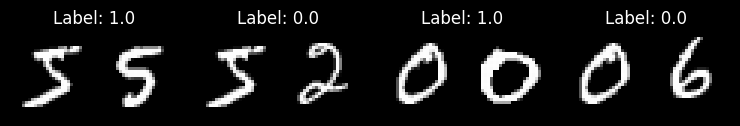

In [ ]:
visualize(X_train_pairs[:-1], y_train_pairs[:-1], to_show = 4, num_col = 4)

In [ ]:
X_train_pairs.shape

(120000, 2, 28, 28)

In [ ]:
## Define the neural network architecture in a functional way
def initialize_base_siamese_network():
  input_layer = Input(shape = (28, 28), name = 'input')
  x = Flatten(name = 'flatten')(input_layer) #do with CNN
  x = Dense(128, activation = tf.nn.leaky_relu, name = 'dense1')(x)
  x = Dropout(0.1, name = 'dropout1')(x)
  x = Dense(128, activation = tf.nn.leaky_relu, name = 'dense2')(x)
  x = Dropout(0.1, name = 'dropout2')(x)
  x = Dense(128, activation = tf.nn.leaky_relu, name = 'dense3')(x)
  return Model(inputs = input_layer, outputs = x)


In [ ]:
## Initialising the base siamese network
network = initialize_base_siamese_network()

In [ ]:
print(type(network))

<class 'keras.src.engine.functional.Functional'>


In [ ]:
import pydot_ng as pydot
pydot.find_graphviz()

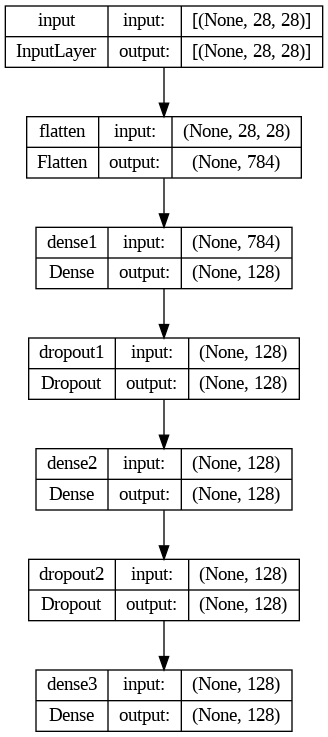

In [ ]:
# Plot the network
plot_model(network,
           show_shapes = True,
           show_layer_names = True
           )

In [ ]:
a = tf.constant([1.,2.,3.])
b = tf.constant([4.,5.,6.])
tf.reshape(tf.norm(a-b), [-1])
#tf.norm(a-b)

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([5.196152], dtype=float32)>

In [ ]:
input_left = Input(shape = (28, 28), name = 'input_left') #Symbolic tensor
output_left = network(input_left) #Symbolic tensor
type(input_left)

keras.src.engine.keras_tensor.KerasTensor

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras import backend as K

In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten

In [ ]:
def CNN_network():

  input_layer = Input(shape = (28, 28, 1), name = 'input')

  x = BatchNormalization(name = 'batchnorm1')(input_layer)
  x = Conv2D(1, kernel_size=(3,3), activation=tf.nn.leaky_relu, name = 'conv1')(x)
  x = MaxPooling2D(pool_size=(2, 2), name = 'maxpool1')(x)

  x = BatchNormalization(name = 'batchnorm2')(input_layer)
  x = Conv2D(1, kernel_size=(3,3), activation=tf.nn.leaky_relu, name = 'conv2')(x)
  x = MaxPooling2D(pool_size=(2, 2), name = 'maxpool2')(x)

  # Flatten the output for feeding into dense layers
  x = Flatten(name = 'flatten1')(x)
  x = BatchNormalization(name = 'batchnorm3')(x)
  x = Dense(32, activation = tf.nn.leaky_relu, name = 'dense1')(x)

  return Model(inputs = input_layer, outputs = x)


In [ ]:
network = CNN_network()

In [ ]:
# Build the siamese neural network architecture
input_left = Input(shape = (28, 28), name = 'input_left')
output_left = network(input_left)

# output_left - functional ouutput acting on functional input working through funactional method

# Weights is shared by the means of network

input_right = Input(shape = (28, 28), name = 'input_right')
output_right = network(input_right)

# Measure the similarity of the outputs correspondidng to inputs a and b
subtracted = Lambda(lambda x:x[0]-x[1], name = 'output_layer')([output_left, output_right]) # eg: 128-vec will be size of the output
output = Lambda(lambda x: tf.math.sqrt(tf.reduce_sum(x**2, axis=1, keepdims=True)))(subtracted)





# # Additional dense layer
# # x = Dense(64, activation = tf.nn.sigmoid, name='dense4')(subtracted)
# x = Dense(32, activation = tf.nn.sigmoid, name='dense5')(subtracted)

# output = Dense(1, activation = tf.nn.sigmoid)(x)

# Specify the inputs and the output of the Siamese neural network
model = Model(inputs = [input_left, input_right], outputs = output)



In [ ]:
type(subtracted)

keras.src.engine.keras_tensor.KerasTensor

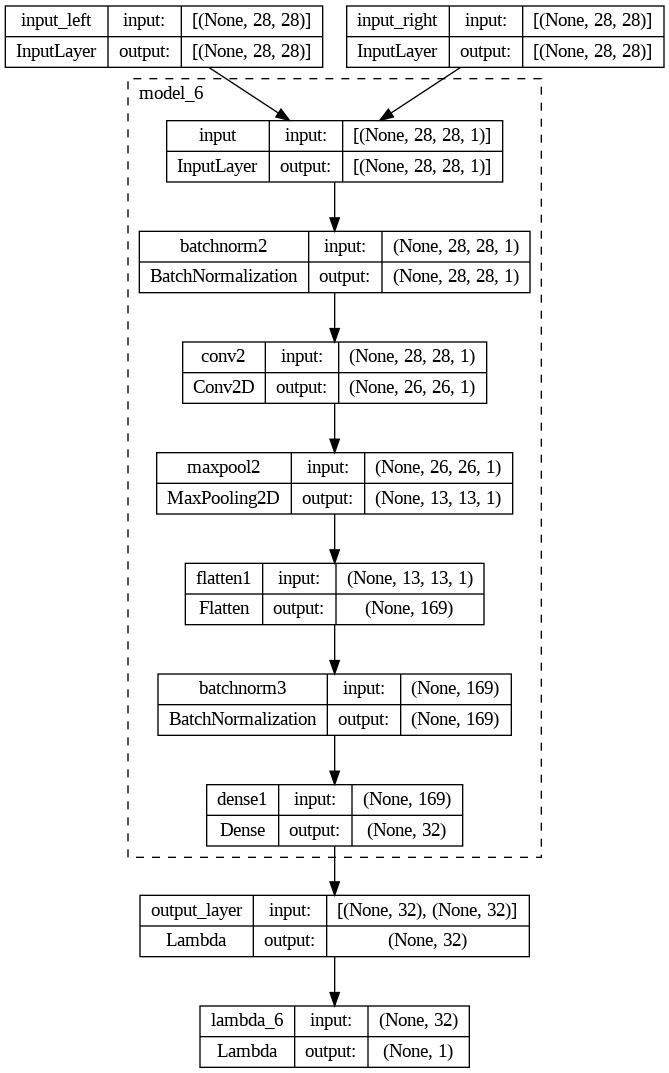

In [ ]:
# Plot the network
plot_model(model,
           show_shapes = True,
           show_layer_names = True,
           expand_nested=True,
           )

In [ ]:
output.shape

TensorShape([None, 1])

In [ ]:
X_train_pairs.shape

(120000, 2, 28, 28)

In [ ]:
X_train_pairs[:, 0].shape # All left images in each sample

(120000, 28, 28)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate = learning_rate) # optimizer
loss_fn = tf.keras.losses.BinaryCrossentropy()  # loss function
model.compile(optimizer = opt, loss = loss_fn, metrics = ['acc'])

# Train model and simultaneously test on the test set
history = model.fit([X_train_pairs[:, 0], [X_train_pairs[:, 1]]],
                     y_train_pairs,
                     batch_size = batch_size,
                     epochs = 50,
                     validation_data = ([X_test_pairs[:, 0],X_test_pairs[:, 1]], y_test_pairs))

Epoch 1/50
469/469 [==============================] - 6s 8ms/step - loss: 0.1937 - acc: 0.9266 - val_loss: 0.2009 - val_acc: 0.9225
Epoch 2/50
469/469 [==============================] - 4s 9ms/step - loss: 0.1872 - acc: 0.9285 - val_loss: 0.2237 - val_acc: 0.9122
Epoch 3/50
469/469 [==============================] - 3s 7ms/step - loss: 0.1804 - acc: 0.9307 - val_loss: 0.1971 - val_acc: 0.9244
Epoch 4/50
469/469 [==============================] - 3s 7ms/step - loss: 0.1748 - acc: 0.9326 - val_loss: 0.1918 - val_acc: 0.9258
Epoch 5/50
469/469 [==============================] - 4s 9ms/step - loss: 0.1704 - acc: 0.9344 - val_loss: 0.1872 - val_acc: 0.9274
Epoch 6/50
469/469 [==============================] - 3s 7ms/step - loss: 0.1666 - acc: 0.9365 - val_loss: 0.1856 - val_acc: 0.9279
Epoch 7/50
469/469 [==============================] - 3s 7ms/step - loss: 0.1626 - acc: 0.9381 - val_loss: 0.2237 - val_acc: 0.9115
Epoch 8/50
469/469 [==============================] - 4s 8ms/step - loss: 0.

In [ ]:
model.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_left (InputLayer)     [(None, 28, 28)]             0         []                            
                                                                                                  
 input_right (InputLayer)    [(None, 28, 28)]             0         []                            
                                                                                                  
 model_6 (Functional)        (None, 32)                   6130      ['input_left[0][0]',          
                                                                     'input_right[0][0]']         
                                                                                                  
 output_layer (Lambda)       (None, 32)                   0         ['model_6[0][0]',       

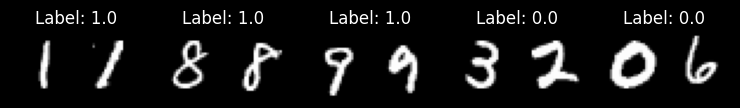

1/1 [==============================] - 0s 22ms/step


array([[0.99978644],
       [0.99739397],
       [0.63067305],
       [0.00449971],
       [0.00156676]], dtype=float32)

In [ ]:
# Visualize
ind = np.random.choice(X_test_pairs.shape[0], 5)
visualize(X_test_pairs[ind], y_test_pairs[ind], to_show = len(ind), num_col = len(ind))
model.predict([X_test_pairs[ind, 0], X_test_pairs[ind, 1]])